# Cohort EDA

Exploratory analysis of the base patient cohort built from MIMIC-IV ED stays. Covers triage vitals distributions, outlier ranges, missingness, acuity, pain, demographics, and cohort label composition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datasets import load_dataset
from data_pipelines.preprocessing_scripts.triage_vitals_preprocessing import fix_triage_outliers, clean_pain_column
from data_pipelines.preprocessing_scripts.cohort_preprocessing import simplify_race_column

ds = load_dataset("ADS599-Capstone/interim_data", name="cohort_full", split="cohort_base", verification_mode="no_checks")
df = ds.to_pandas()


# Dataset Overview

In [5]:
df.columns

Index(['subject_id', 'ed_stay_id', 'hadm_id', 'ed_intime', 'ed_outtime',
       'disposition', 'race', 'arrival_transport', 'first_careunit',
       'first_icu_intime', 'cohort_label', 'gender', 'anchor_age',
       'anchor_year', 'age_at_visit', 'dod', 'admittime', 'dischtime',
       'admission_type', 'discharge_location', 'insurance', 'language',
       'marital_status', 'ed_stay_id_2', 'stay_window_start',
       'stay_window_end', 'ed_boarding_time_hrs', 'temperature', 'heartrate',
       'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint'],
      dtype='str')

In [2]:
print(f"Number of patients: {df['subject_id'].nunique()}")
print(f"Unique number of ED stays: {df['ed_stay_id'].nunique()}")
print(f"Unique number of hospital admissions: {df['hadm_id'].nunique()}")

Number of patients: 196406
Unique number of ED stays: 397675
Unique number of hospital admissions: 192201


The cohort covers adult ED visits from MIMIC-IV with a provider disposition of home or admitted. Each row is one ED stay.

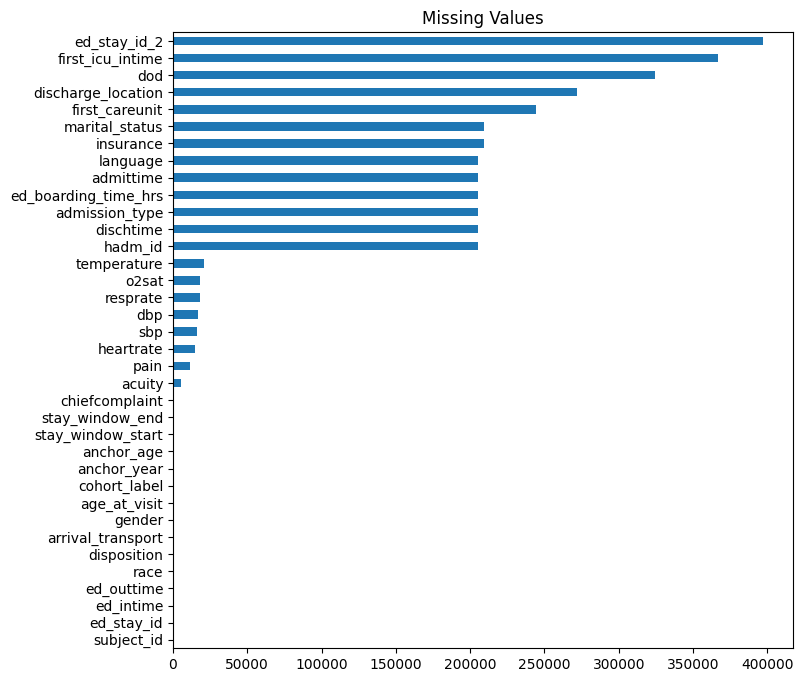

In [3]:
missing_values = df.isna().sum()
missing_values.sort_values().plot(kind='barh', figsize = (8,8), title='Missing Values')
plt.show()

# Triage Stats Check

Not using `chief_complaint` in the model so not exploring here

Not concerned with outliers in `acuity`, only missing values

The `pain` column is a mix of integer and string so needs to be handled differently

## Outliers

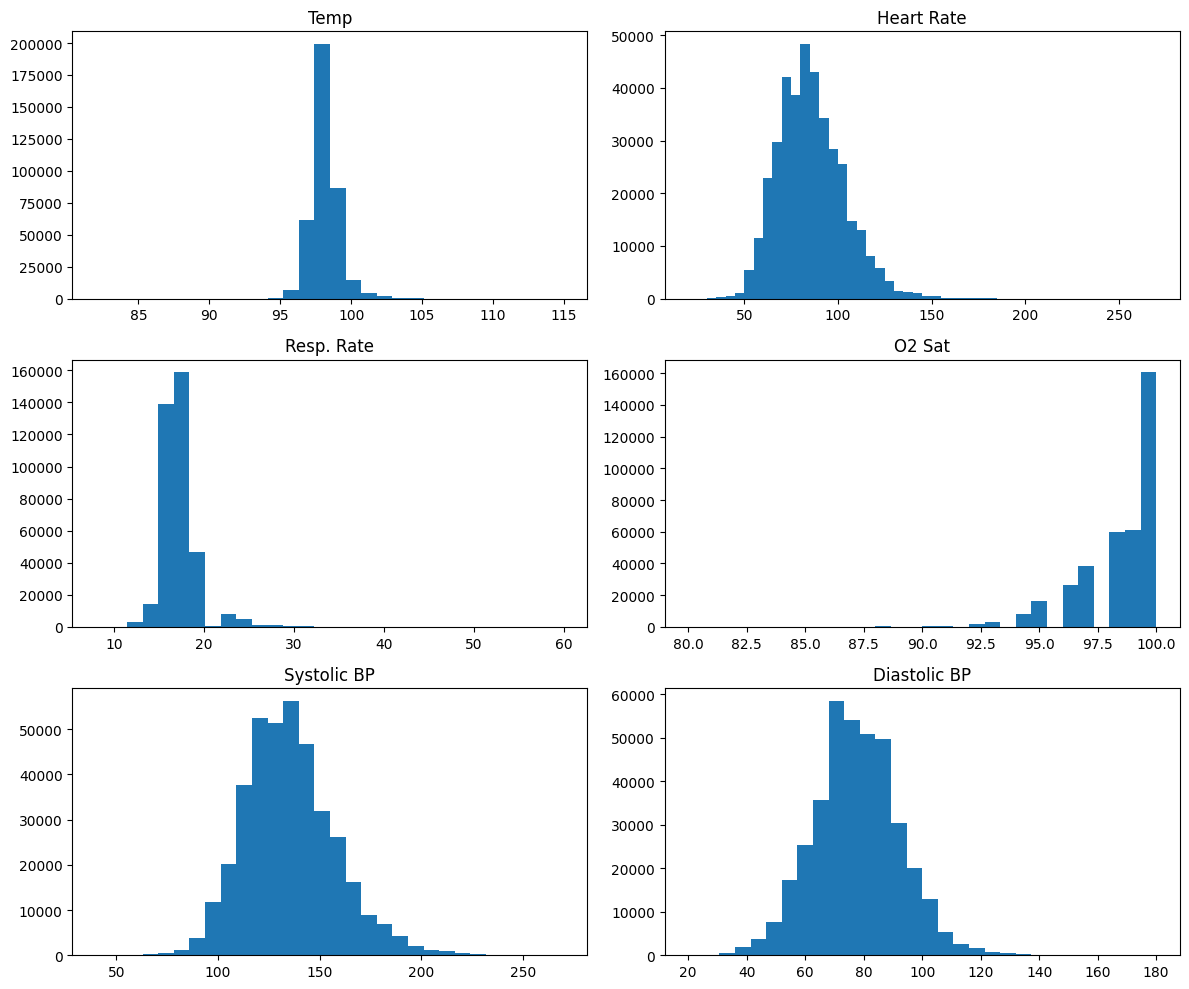

In [46]:
fig, axs = plt.subplots(3, 2, figsize= (12, 10))
ax = axs.flatten()

ax[0].hist(df['temperature'].dropna(), range = (82, 115), bins=30)
ax[1].hist(df['heartrate'].dropna(), range = (20, 270), bins=50)
ax[2].hist(df['resprate'].dropna(), range = (8, 60), bins=30)
ax[3].hist(df['o2sat'].dropna(), range = (80, 100), bins=30)
ax[4].hist(df['sbp'].dropna(), range = (40, 270), bins=30)
ax[5].hist(df['dbp'].dropna(), range = (20, 180), bins=30)

ax[0].set_title("Temp")
ax[1].set_title("Heart Rate")
ax[2].set_title("Resp. Rate")
ax[3].set_title("O2 Sat")
ax[4].set_title("Systolic BP")
ax[5].set_title("Diastolic BP")

plt.tight_layout()
plt.show()

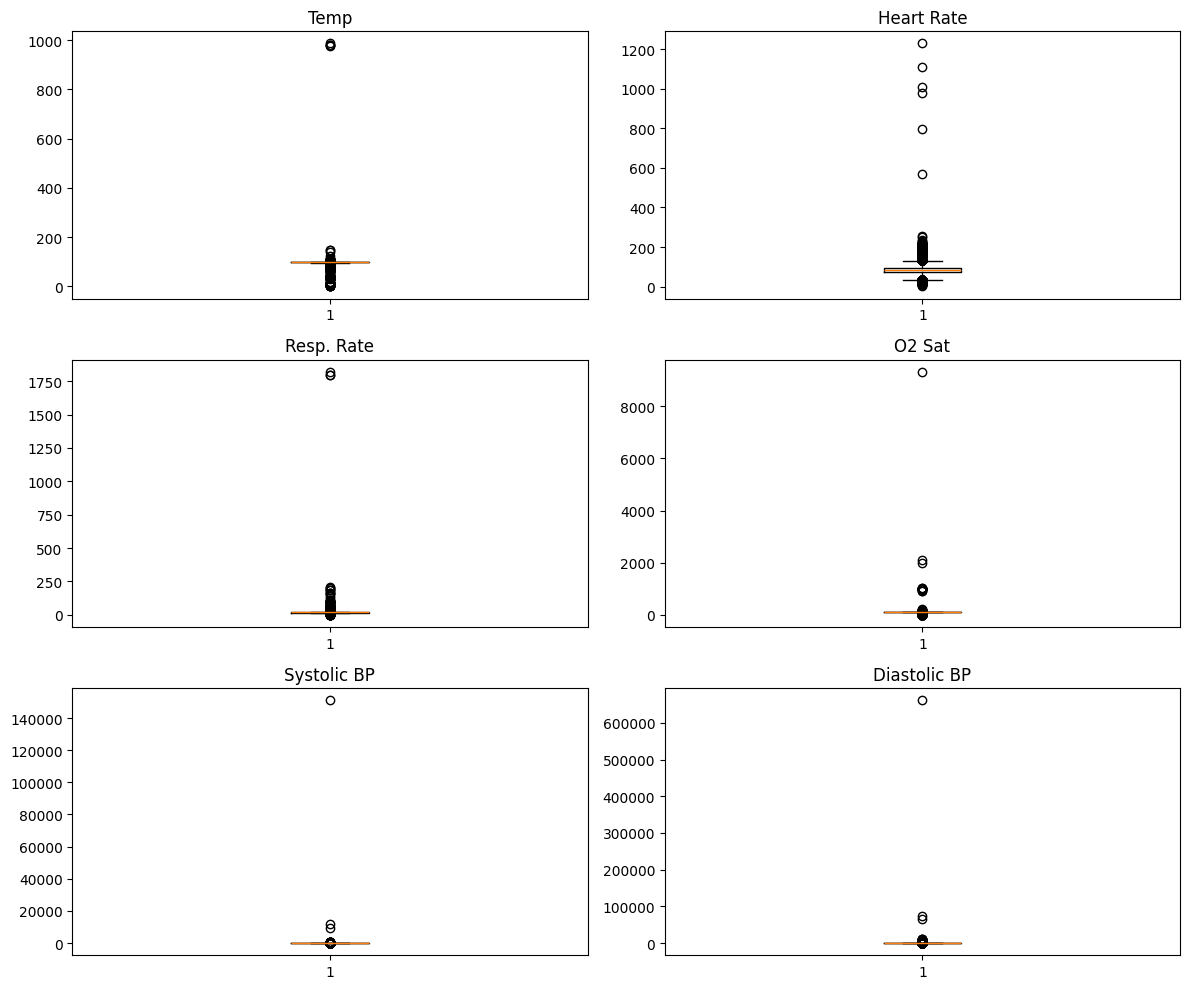

In [26]:
fig, axs = plt.subplots(3, 2, figsize= (12, 10))
ax = axs.flatten()

ax[0].boxplot(df['temperature'].dropna())
ax[1].boxplot(df['heartrate'].dropna())
ax[2].boxplot(df['resprate'].dropna())
ax[3].boxplot(df['o2sat'].dropna())
ax[4].boxplot(df['sbp'].dropna())
ax[5].boxplot(df['dbp'].dropna())

ax[0].set_title("Temp")
ax[1].set_title("Heart Rate")
ax[2].set_title("Resp. Rate")
ax[3].set_title("O2 Sat")
ax[4].set_title("Systolic BP")
ax[5].set_title("Diastolic BP")

plt.tight_layout()
plt.show()

In [3]:
triage_check = df[['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']]

Q1 = triage_check.quantile(q=0.25, axis=0)
Q3 = triage_check.quantile(q=0.75, axis=0)
IQR = Q3 - Q1

upper_outliers = Q3 + (1.5 * IQR)
lower_outliers = Q1 - (1.5 * IQR)

triage_cols = triage_check.columns

In [4]:
print(f"\n--- NA counts per triage column ---")
for col in triage_cols:
    n_null = df[col].isna().sum()
    n_total = len(df)
    print(f"  {col:<15} null: {n_null:,} / {n_total:,}  ({n_null/n_total:.1%})")

print(f"\n--- Value ranges for non-null triage values ---")
print(df[triage_cols].describe().round(2))


--- NA counts per triage column ---
  temperature     null: 20,901 / 397,675  (5.3%)
  heartrate       null: 14,981 / 397,675  (3.8%)
  resprate        null: 18,060 / 397,675  (4.5%)
  o2sat           null: 18,257 / 397,675  (4.6%)
  sbp             null: 16,084 / 397,675  (4.0%)
  dbp             null: 16,842 / 397,675  (4.2%)

--- Value ranges for non-null triage values ---
       temperature  heartrate   resprate      o2sat        sbp        dbp
count    376774.00  382694.00  379615.00  379418.00  381591.00  380833.00
mean         98.02      84.98      17.58      98.48     135.50      81.20
std           4.07      18.05       5.64      17.59     246.69    1088.14
min           0.10       1.00       0.00       0.00       1.00       0.00
25%          97.50      72.00      16.00      97.00     120.00      68.00
50%          98.00      83.00      18.00      99.00     133.00      77.00
75%          98.60      96.00      18.00     100.00     148.00      87.00
max         986.00    1228.0

In [ ]:
print(f"{'Column':<15} {'Lower Thresh':>14} {'Upper Thresh':>14} {'# Below Lower':>14} {'# Above Upper':>14} {'Low Range':>20} {'High Range':>20}")
print("-" * 105)
for col in triage_cols:
    lo = lower_outliers[col]
    hi = upper_outliers[col]
    low_vals = triage_check[col][triage_check[col] < lo]
    high_vals = triage_check[col][triage_check[col] > hi]
    n_lo = len(low_vals)
    n_hi = len(high_vals)
    low_range = f"[{low_vals.min():.2f}, {low_vals.max():.2f}]" if n_lo > 0 else "none"
    high_range = f"[{high_vals.min():.2f}, {high_vals.max():.2f}]" if n_hi > 0 else "none"
    print(f"{col:<15} {lo:>14.2f} {hi:>14.2f} {n_lo:>14,} {n_hi:>14,} {low_range:>20} {high_range:>20}")

Column            Lower Thresh   Upper Thresh  # Below Lower  # Above Upper            Low Range           High Range
---------------------------------------------------------------------------------------------------------
temperature              95.85         100.25          2,275          9,554        [0.10, 95.80]     [100.30, 986.00]
heartrate                36.00         132.00            227          4,185        [1.00, 35.00]    [133.00, 1228.00]
resprate                 13.00          21.00          2,839         17,394        [0.00, 12.00]     [22.00, 1820.00]
o2sat                    92.50         104.50          4,926             46        [0.00, 92.00]    [107.00, 9322.00]
sbp                      78.00         190.00            912          6,506        [1.00, 77.00]  [191.00, 151103.00]
dbp                      39.50         115.50          1,756          3,824        [0.00, 39.00]  [116.00, 661672.00]


## Acuity

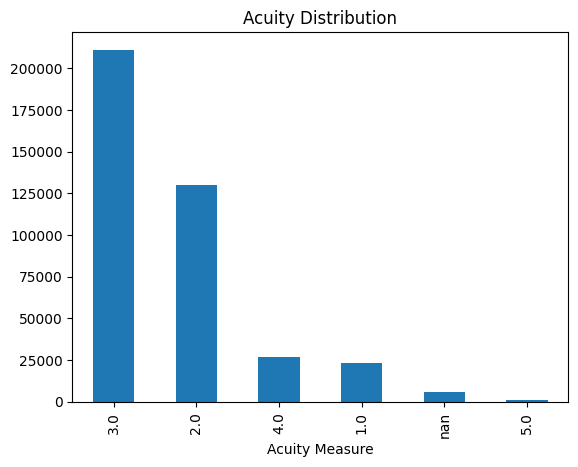

In [8]:
df['acuity'].value_counts(dropna=False).plot(kind='bar', title='Acuity Distribution')
plt.xlabel("Acuity Measure")
plt.show()

## Pain

In [8]:
df['pain'].value_counts()

pain
0                  131097
8                   39103
10                  37947
7                   29569
5                   27719
                    ...  
utts                    1
urta                    1
CRITICAL                1
unable critical         1
UNABLE                  1
Name: count, Length: 802, dtype: int64

In [ ]:
df = clean_pain_column(df)

df['pain'].value_counts()

# Missing Value Strategy

Triage vitals are handled using clinically plausible range clipping followed by forward fill, backward fill, and column-level mean imputation within each stay. KNN and iterative imputation were explored here but the production pipeline uses mean imputation for remaining NaNs after ff/bfill. See `data_pipelines/pipeline_scripts/triage_vitals_pipeline.py` for the final approach.

# Demographics

In [95]:
demo_cols = ['marital_status', 'insurance', 'language']

<Axes: xlabel='marital_status'>

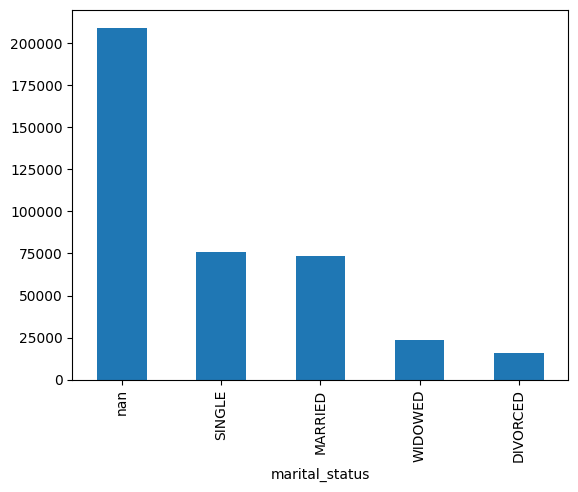

In [96]:
df.value_counts('marital_status', dropna=False).plot(kind='bar')

Fill nan with unknown

<Axes: xlabel='insurance'>

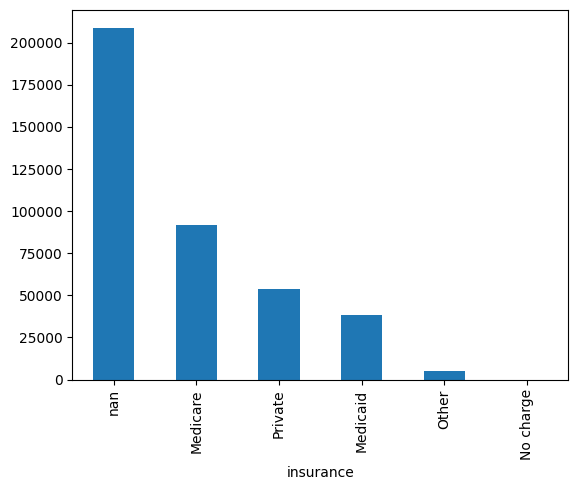

In [97]:
df.value_counts('insurance', dropna=False).plot(kind='bar')

We'll fill the nan with unknown

<Axes: xlabel='language'>

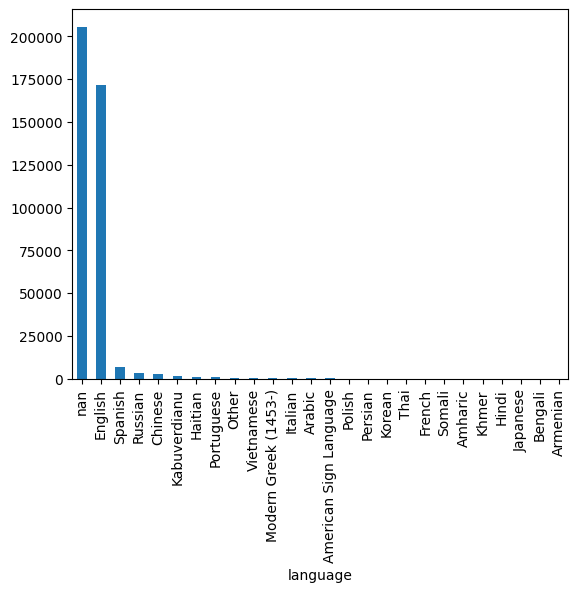

In [98]:
df.value_counts('language', dropna=False).plot(kind='bar')

We'll fill nan with 'Unknown' and separate the rest into English and non-english

In [106]:
df[df[demo_cols].isna().any(axis=1)].value_counts('cohort_label', dropna=False)

cohort_label
ED_DISCHARGE_STABLE        206714
ED_WARD_DISCHARGE            2934
ED_DIRECT_ICU                2436
ED_DISCHARGE_RETURN_ICU       219
ED_WARD_ICU                   205
ED_DISCHARGE_DIED_72H          58
Name: count, dtype: int64

Mostly because the patients didn't have a hospital stay with a few thousand that are just unknown

<Axes: ylabel='race'>

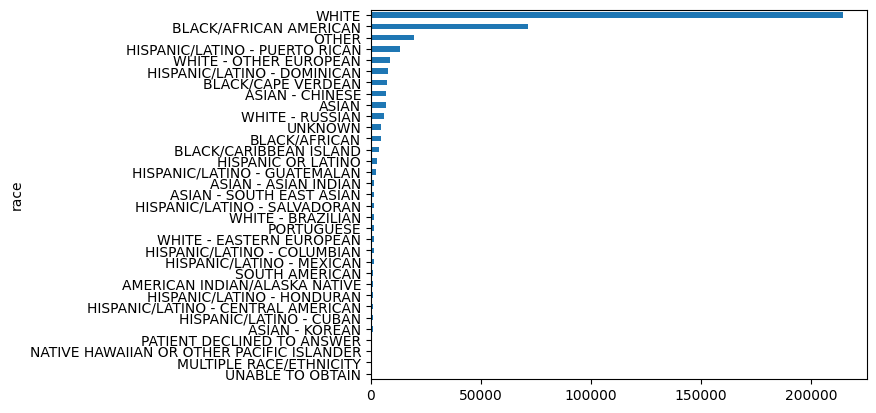

In [ ]:
df['race'].value_counts().sort_values().plot(kind='barh')

Race is highly concentrated in a small number of categories. This reflects both the institution's patient population (Beth Israel Deaconess, Boston) and the known underrepresentation of some groups in EHR data.

<Axes: ylabel='Frequency'>

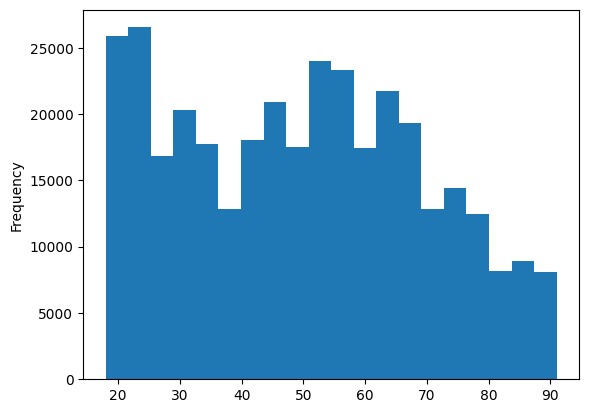

In [10]:
df['anchor_age'].plot(kind='hist', bins=20)

Age distribution is broad with a concentration in middle and older adult ranges, consistent with typical ED utilization patterns.

<Axes: xlabel='gender'>

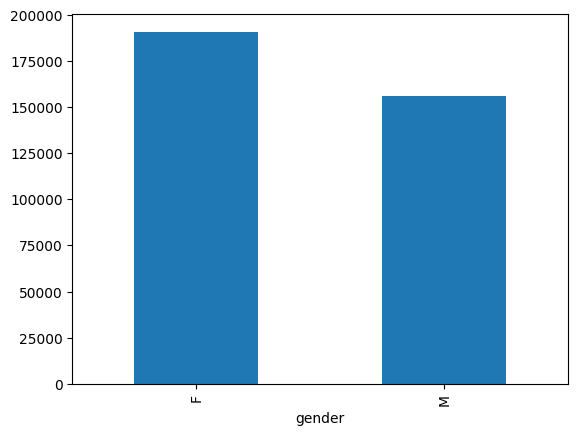

In [9]:
df['gender'].value_counts().plot(kind='bar')

Roughly balanced gender split across the cohort. Minor gender differences in presentation patterns are expected in ED populations.

# Cohort Label Investigation

In [151]:
df['cohort_label'].value_counts()

cohort_label
ED_DISCHARGE_STABLE        240889
ED_WARD_DISCHARGE          125377
ED_DIRECT_ICU               22643
ED_WARD_ICU                  8419
ED_DISCHARGE_RETURN_ICU       275
ED_DISCHARGE_DIED_72H          72
Name: count, dtype: int64

The binary modeling label collapses `ED_DIRECT_ICU` and `ED_WARD_ICU` into `transfer_icu`, and `ED_DISCHARGE_STABLE` and `ED_DISCHARGE_RETURN_ICU` into `discharge`. Stays labeled `ED_DISCHARGE_DIED_72H` and `ED_WARD_DISCHARGE` are excluded from the modeling cohort.

In [ ]:
df[df['discharge_location'] == 'DIED'].value_counts('cohort_label')

cohort_label
ED_DIRECT_ICU            2756
ED_WARD_ICU              1059
ED_WARD_DISCHARGE         631
ED_DISCHARGE_STABLE        10
ED_DISCHARGE_DIED_72H       3
Name: count, dtype: int64

In [20]:
pd.set_option("display.max_columns", 36)

df[(df['discharge_location'] == 'DIED') & (df['cohort_label'] == 'ED_DISCHARGE_DIED_72H')]

,subject_id,ed_stay_id,hadm_id,ed_intime,ed_outtime,disposition,race,arrival_transport,first_careunit,first_icu_intime,cohort_label,gender,anchor_age,anchor_year,age_at_visit,dod,admittime,dischtime,admission_type,discharge_location,insurance,language,marital_status,ed_stay_id_2,stay_window_start,stay_window_end,ed_boarding_time_hrs,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint
283804,11397486,32034671,21349946.0,2127-10-09 04:52:00,2127-10-09 07:54:00,HOME,UNKNOWN,UNKNOWN,Medical Intensive Care Unit (MICU),2127-10-09 07:54:00,ED_DISCHARGE_DIED_72H,F,91,2127,91,2127-10-11,2127-10-09 06:08:00,2127-10-11 07:02:00,EW EMER.,DIED,Medicare,English,NaN,NaN,2127-10-09 04:52:00,2127-10-11 07:02:00,6360.0,94.8,40.0,16.0,98.0,90.0,48.0,13,1.0,GIB
317981,15987154,33188868,21595480.0,2188-07-21 06:29:00,2188-07-21 08:42:29,HOME,UNKNOWN,UNKNOWN,Trauma SICU (TSICU),2188-07-21 08:42:29,ED_DISCHARGE_DIED_72H,M,24,2188,24,2188-07-21,2188-07-21 08:41:00,2188-07-21 19:45:00,EW EMER.,DIED,Private,English,NaN,NaN,2188-07-21 06:29:00,2188-07-21 19:45:00,89.0,NaN,NaN,NaN,NaN,NaN,NaN,ETT,1.0,STAT TRAUMA
370460,15175605,38418225,29718793.0,2130-07-12 20:06:00,2130-07-13 02:40:00,HOME,WHITE,AMBULANCE,Medical/Surgical Intensive Care Unit (MICU/SICU),2130-07-13 02:40:00,ED_DISCHARGE_DIED_72H,M,51,2130,51,2130-07-15,2130-07-12 23:44:00,2130-07-15 18:30:00,OBSERVATION ADMIT,DIED,Medicaid,English,MARRIED,NaN,2130-07-12 20:06:00,2130-07-15 18:30:00,10560.0,98.0,89.0,16.0,95.0,122.0,83.0,5,3.0,"Abd pain, Transfer"


# The Rest of the Columns

- `ed_stay_id_2`: This is a tracking column for patients that were discharged from ER and instantly readmitted
- `first_icu_intime`: This is to be used as ending time for patients who were sent from ED or Ward to ICU
- `dod`: Not needed for anything
- `discharge location`: Only needed to know which patients died in hospital
- `first_care_unit`: Not needed
- `admittime`: Needed for timing on when patient was sent to hospital
- `ed_boarding_time_hours`: Not needed for main RL policy training
- `admission_type`: Used for patient state
- `dischtime`: Used for terminal state on patients sent to hospital but not ICU
- `stay_window_state and _end`: For patients not sent to ICU, this is their full length of stay
- `arrival_transport`: Used in patient state
- `disposition`: Not used in patient state, only used to distinguish between patients sent to hospital or not
- `ed_intime and _outtime`: Used in time series creation for transition between a patient leaving the ER and going to the ward or icu